In [1]:
!pip install prophet

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import datetime
from math import sqrt
from datetime import datetime, timedelta

In [4]:
ticker = "AAPL"

end_date = datetime.today()

start_date = end_date - timedelta(days=5*365)

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-06-04,122.711517,122.974705,120.723023,120.937469,75169300
2021-06-07,122.721275,123.130669,121.678291,122.984455,71057600
2021-06-08,123.540054,125.216636,123.023437,123.403590,74403800
2021-06-09,123.920197,124.524545,123.325597,123.998178,56877900
2021-06-10,122.925957,124.953442,122.760251,123.812977,71186400


In [5]:
df = df.reset_index()

In [6]:
df = df[['Date', 'Close']]

In [7]:
df.columns = ['ds', 'y']

In [8]:
df['ds'] = pd.to_datetime(df['ds'])

In [9]:
print(df.shape)

df.info()

print(df.isnull().sum())

(1254, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1254 non-null   datetime64[ns]
 1   y       1254 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.7 KB
ds    0
y     0
dtype: int64


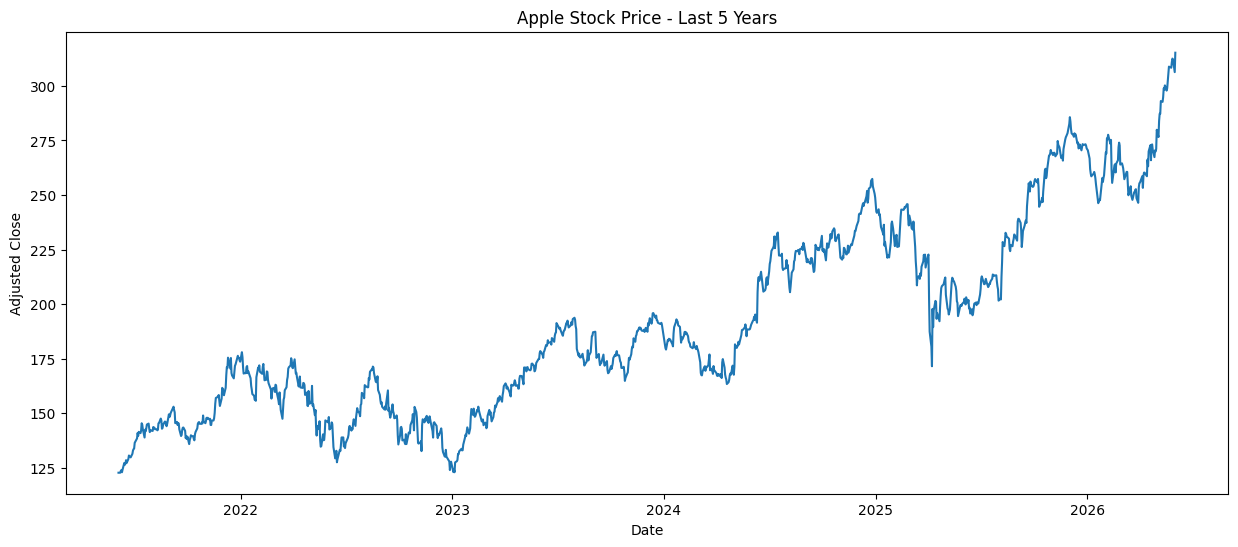

In [10]:
plt.figure(figsize=(15,6))

plt.plot(df['ds'], df['y'])

plt.title("Apple Stock Price - Last 5 Years")

plt.xlabel("Date")

plt.ylabel("Adjusted Close")

plt.show()

In [11]:
df['MA30'] = df['y'].rolling(30).mean()

df['MA90'] = df['y'].rolling(90).mean()

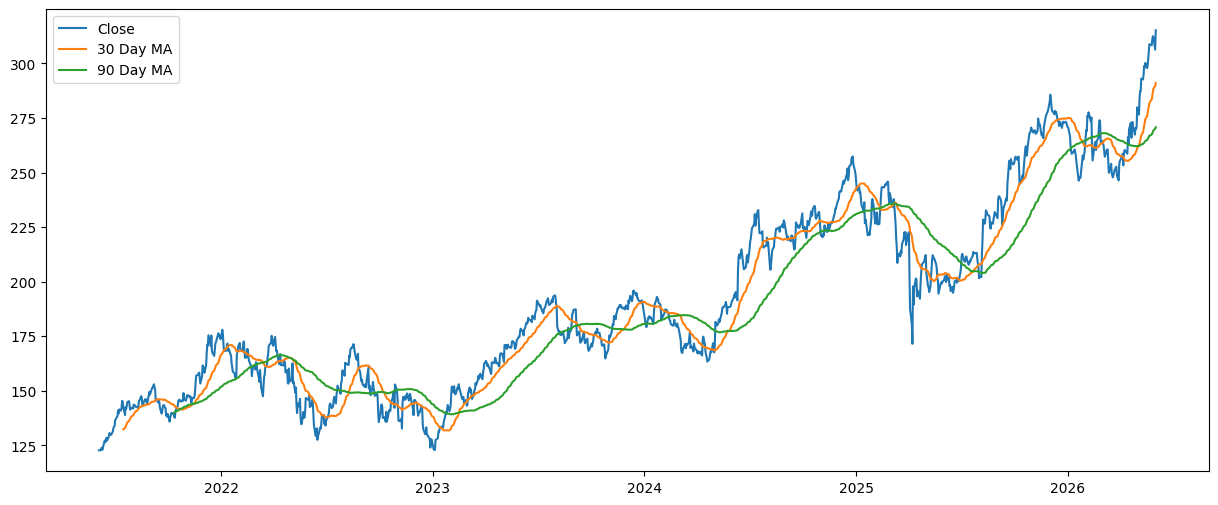

In [12]:
plt.figure(figsize=(15,6))

plt.plot(df['ds'], df['y'], label='Close')

plt.plot(df['ds'], df['MA30'], label='30 Day MA')

plt.plot(df['ds'], df['MA90'], label='90 Day MA')

plt.legend()

plt.show()

In [13]:
test_days = 180

train = df[:-test_days]

test = df[-test_days:]

In [14]:
train_prophet = train[['ds', 'y']]

test_prophet = test[['ds', 'y']]

In [15]:
model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

In [16]:
model.fit(train_prophet)

In [17]:
future = model.make_future_dataframe(
    periods=test_days,
    freq='B'
)

In [18]:
forecast = model.predict(future)

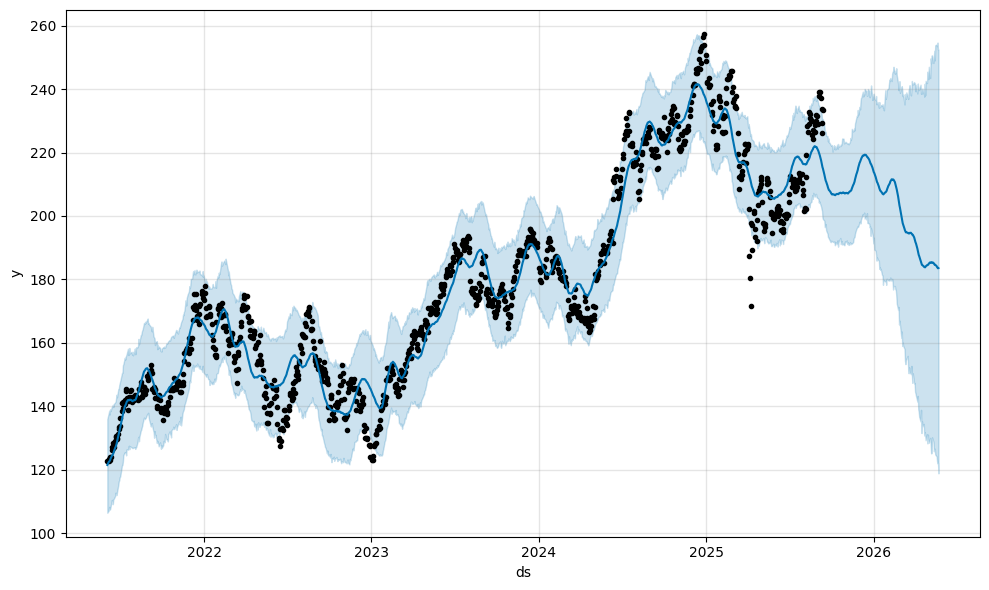

In [19]:
fig = model.plot(forecast)

plt.show()

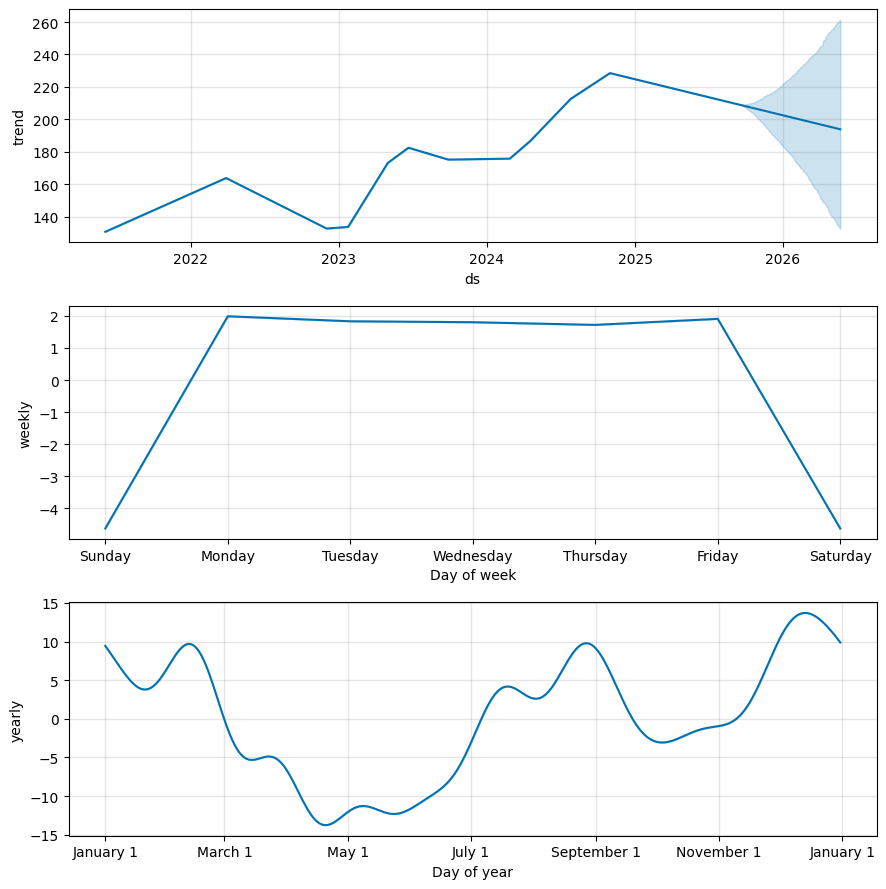

In [20]:
fig2 = model.plot_components(forecast)

plt.show()

In [21]:
pred = forecast[['ds','yhat']]

pred = pred.tail(len(test_prophet))

pred.reset_index(drop=True, inplace=True)

test_prophet.reset_index(drop=True, inplace=True)

In [22]:
comparison = pd.DataFrame({
    'Date': test_prophet['ds'],
    'Actual': test_prophet['y'],
    'Predicted': pred['yhat']
})

comparison.head()

,Date,Actual,Predicted
0,2025-09-15,236.032242,213.133991
1,2025-09-16,237.478149,212.384695
2,2025-09-17,238.315796,211.783550
3,2025-09-18,237.208923,211.152831
4,2025-09-19,244.807404,210.820947


In [23]:
rmse = sqrt(
    mean_squared_error(
        comparison['Actual'],
        comparison['Predicted']
    )
)

print("RMSE:", rmse)

RMSE: 67.48227562321061


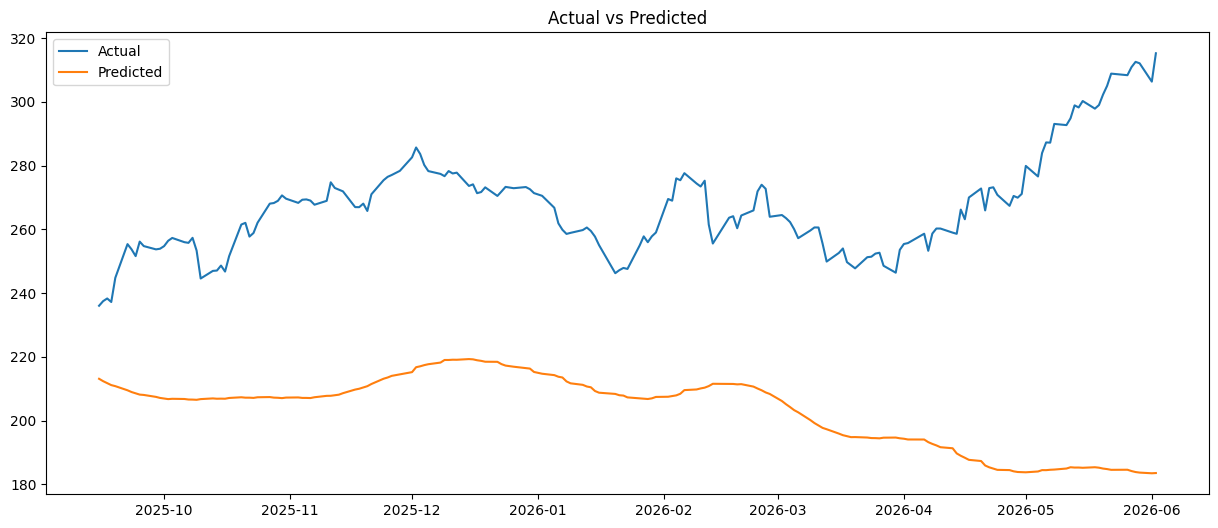

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison['Date'],
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Date'],
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [27]:
final_model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    yearly_seasonality=True,
    weekly_seasonality=True
)

final_model.fit(df[['ds','y']])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [28]:
future_dates = final_model.make_future_dataframe(
    periods=90,
    freq='B'
)

In [29]:
future_forecast = final_model.predict(
    future_dates
)

In [30]:
future_forecast[
    ['ds',
     'yhat',
     'yhat_lower',
     'yhat_upper']
].tail(30)

,ds,yhat,yhat_lower,yhat_upper
1314,2026-08-26,324.154124,310.956376,336.711818
1315,2026-08-27,324.041929,310.249925,337.980296
1316,2026-08-28,324.374857,310.971450,337.604821
1317,2026-08-31,324.731232,310.589311,339.206864
1318,2026-09-01,324.704693,309.853683,337.786714
1319,2026-09-02,324.711078,309.692001,338.569701
1320,2026-09-03,324.441588,310.323717,338.304534
1321,2026-09-04,324.649122,309.694495,339.232765
1322,2026-09-07,324.825084,310.247264,339.324260
1323,2026-09-08,324.800947,311.030731,338.206243


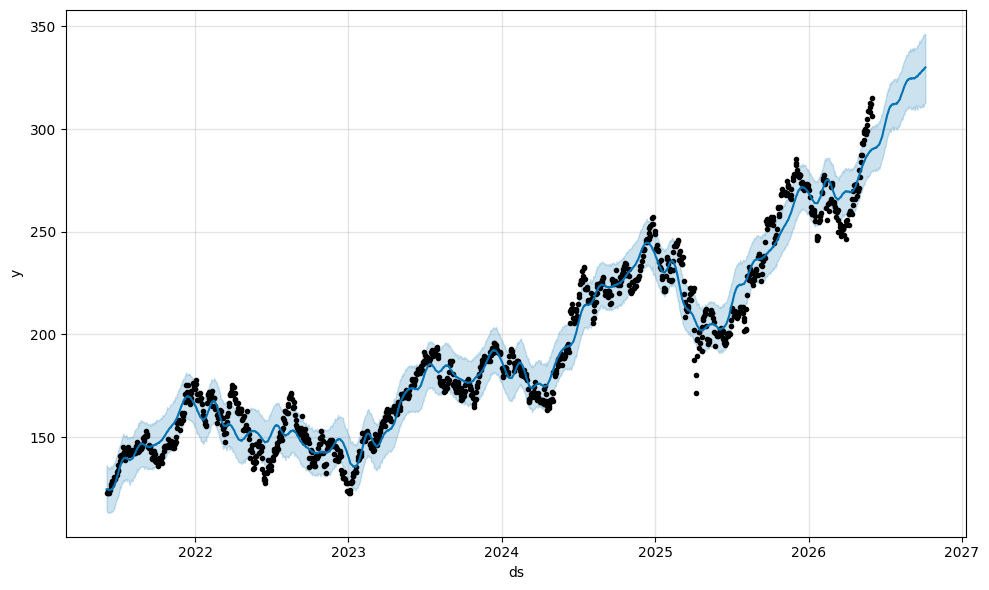

In [31]:
final_model.plot(
    future_forecast
)

plt.show()